In [2]:
# ==============================
# 1. Install & Import
# ==============================

import cv2
import numpy as np
from matplotlib import pyplot as plt
from google.colab import files
import zipfile
import os

In [3]:
# ==============================
# 2. Upload ZIP Project
# ==============================
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("project")

Saving Miniproject Colourizer.zip to Miniproject Colourizer.zip


In [6]:
# ==============================
# 3. Download Model File
# ==============================
!wget -O "project/Miniproject Colourizer/colorize/colorization_release_v2.caffemodel" \
https://www.dropbox.com/s/dx0qvhhp5hbcx7z/colorization_release_v2.caffemodel?dl=1

--2026-04-03 09:44:12--  https://www.dropbox.com/s/dx0qvhhp5hbcx7z/colorization_release_v2.caffemodel?dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.71.18, 2620:100:6021:18::a27d:4112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.71.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/10trr00en4l9vlu7qdcns/colorization_release_v2.caffemodel?rlkey=swcyey8s785ttjv2p2jsjcz3d&dl=1 [following]
--2026-04-03 09:44:13--  https://www.dropbox.com/scl/fi/10trr00en4l9vlu7qdcns/colorization_release_v2.caffemodel?rlkey=swcyey8s785ttjv2p2jsjcz3d&dl=1
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc9b5a1c6ca8a676aa44bbeab32c.dl.dropboxusercontent.com/cd/0/inline/C97nHaxZveJ9VSNwTuAWqcWnWavB2uDB4aIkCwj91il2ou1P_YQGGL7YeJ7QmzKTeSn-gGtSoDVzxeCqEknJ7IuiNpKNrMkhfxg-CtZAqqXH3oG82i5l3eOE0JuA8m6da5E/file?dl=1# [following]
--2026-04-03 09:44:13--  https://

In [7]:
import os

# ==============================
# 4. Load Model
# ==============================
DIR = "project/Miniproject Colourizer/colorize"
os.makedirs(DIR, exist_ok=True)

PROTOTXT = DIR + "/colorization_deploy_v2.prototxt"
POINTS = DIR + "/pts_in_hull.npy"
MODEL = DIR + "/colorization_release_v2.caffemodel"

net = cv2.dnn.readNetFromCaffe(PROTOTXT, MODEL)
pts = np.load(POINTS)

# Load cluster centers
class8 = net.getLayerId("class8_ab")
conv8 = net.getLayerId("conv8_313_rh")

pts = pts.transpose().reshape(2, 313, 1, 1)
net.getLayer(class8).blobs = [pts.astype("float32")]
net.getLayer(conv8).blobs = [np.full([1, 313], 2.606, dtype="float32")]

In [8]:
# ==============================
# 5. Upload Image
# ==============================
print("Upload your grayscale image:")
uploaded_img = files.upload()

img_path = list(uploaded_img.keys())[0]

Upload your grayscale image:


Saving nature.jpg to nature.jpg


In [9]:
# ==============================
# 6. Process Image
# ==============================
image = cv2.imread(img_path)

scaled = image.astype("float32") / 255.0
lab = cv2.cvtColor(scaled, cv2.COLOR_BGR2LAB)

resized = cv2.resize(lab, (224, 224))
L = cv2.split(resized)[0]
L -= 50

net.setInput(cv2.dnn.blobFromImage(L))
ab = net.forward()[0].transpose((1, 2, 0))
ab = cv2.resize(ab, (image.shape[1], image.shape[0]))

L = cv2.split(lab)[0]
colorized = np.concatenate((L[:, :, np.newaxis], ab), axis=2)

colorized = cv2.cvtColor(colorized, cv2.COLOR_LAB2BGR)
colorized = np.clip(colorized, 0, 1)
colorized = (255 * colorized).astype("uint8")

In [10]:
# SAVE IMAGE HERE
cv2.imwrite("output.jpg", colorized)

True

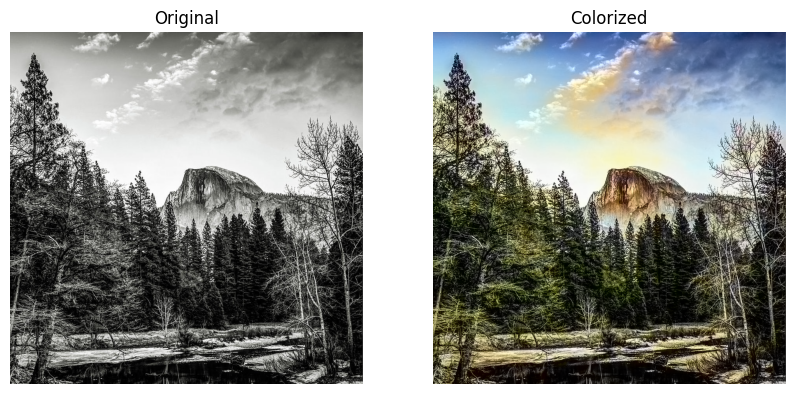

In [11]:
# ==============================
# 7. Display Result
# ==============================
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(colorized, cv2.COLOR_BGR2RGB))
plt.title("Colorized")
plt.axis("off")

plt.show()